# 🚢 Day 001 — Titanic Survival Classifier (Part 1)
**Phase 3: Logistic Regression Deep Dive | Weekend Project 01**

---

### 🎯 Today's Goal:
Load the Titanic dataset, perform Exploratory Data Analysis (EDA), engineer new features, build a preprocessing pipeline, and train a baseline Logistic Regression model.

### 📦 Dataset:
Kaggle Titanic dataset (`train.csv`) — https://www.kaggle.com/c/titanic/data

### 📚 Column Definitions:
| Column | Meaning |
|---|---|
| `PassengerId` | Unique ID for each passenger |
| `Survived` | 0 = Died, 1 = Survived (this is our **target**) |
| `Pclass` | Ticket class — 1 = 1st (Rich), 2 = 2nd, 3 = 3rd (Poor) |
| `Name` | Passenger's name |
| `Sex` | male or female |
| `Age` | Age (some values are missing) |
| `SibSp` | Number of siblings/spouses aboard the Titanic |
| `Parch` | Number of parents/children aboard the Titanic |
| `Ticket` | Ticket number |
| `Fare` | Passenger fare |
| `Cabin` | Cabin number (lots of missing values) |
| `Embarked` | Port of embarkation — C = Cherbourg, Q = Queenstown, S = Southampton |

---
## 🛠️ Step 1: Import Libraries and Load Dataset

### What to do:
1. Import these libraries: `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`
2. Load the `train.csv` file using `pd.read_csv()` and store it in a variable named `df`
3. Print these 4 items:
   - `df.shape` → number of rows and columns
   - `df.head()` → shows first 5 rows
   - `df.info()` → data type of each column and missing value counts
   - `df.isnull().sum()` → column-wise missing value counts

### What does this mean:
- The first step in any ML project is to **understand the data**.
- `.shape` shows the dimensions/size of the dataset.
- `.info()` tells us which columns contain numbers, which contain text, and where data is missing.
- `.isnull().sum()` specifically shows us that **Age has ~177, Cabin has ~687, and Embarked has ~2** missing values — which we will handle later.

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [70]:
df=pd.read_csv('train.csv')

In [71]:
df.shape

(891, 12)

In [72]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [74]:
df.drop(columns=['Cabin'],inplace=True)

In [115]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
FamilySize     0
IsAlone        0
dtype: int64

In [116]:
pd.get_dummies(df,columns=['Embarked'])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Title,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Mr,2,0,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,Mrs,2,0,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Miss,1,1,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,Mrs,2,0,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Mr,1,1,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,Rare,1,1,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,Miss,1,1,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,Miss,4,0,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,Mr,1,1,True,False,False


---
## 📊 Step 2: EDA — Understand Patterns through Visualizations

### What to do:
1. Create a bar chart of the `Survived` column using `sns.countplot()` to see how many survived vs died.
2. Create a countplot of `Survived` with `hue='Sex'` to compare survival rates of males vs females.
3. Create a countplot of `Survived` with `hue='Pclass'` to compare 1st/2nd/3rd class survival rates.
4. Plot the distribution of the `Age` column using `sns.histplot()`.

### What does this mean:
- The purpose of EDA is to **discover hidden patterns in the data** before building a model.
- You will observe that the **survival rate of females was much higher than males** (~74% vs ~19%).
- **1st class passengers** had a higher survival rate than 3rd class passengers because they were prioritized for lifeboats.
- These patterns confirm that `Sex` and `Pclass` are **very strong features** for the model.

<Axes: xlabel='Survived', ylabel='count'>

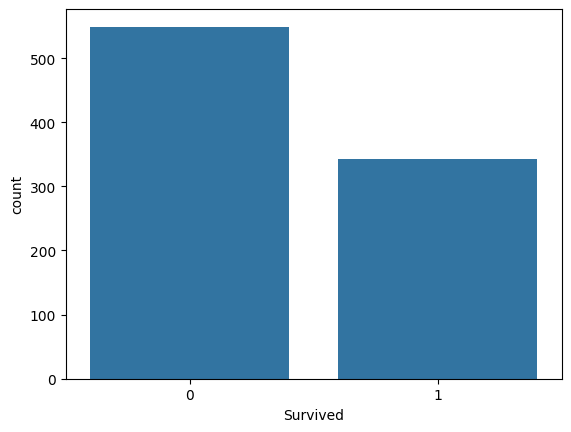

In [117]:
sns.countplot(x='Survived',data=df)

<Axes: xlabel='Survived', ylabel='count'>

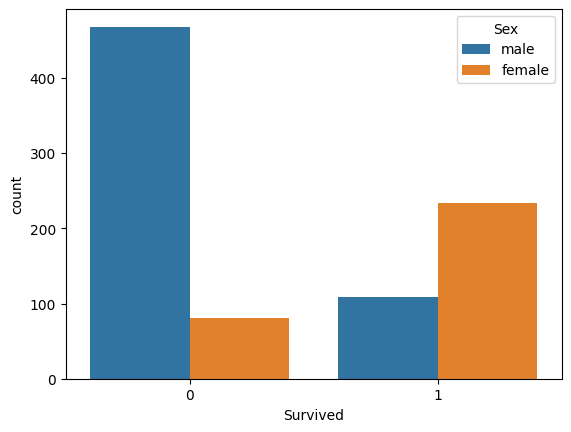

In [118]:
sns.countplot(x='Survived',data=df,hue='Sex')

<Axes: xlabel='Survived', ylabel='count'>

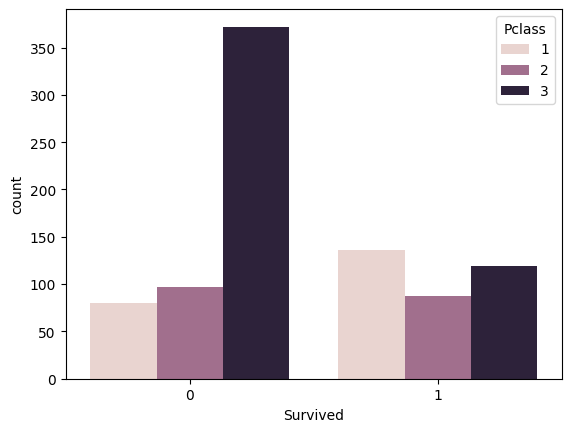

In [119]:
sns.countplot(x='Survived',data=df,hue='Pclass')

<Axes: xlabel='Survived', ylabel='count'>

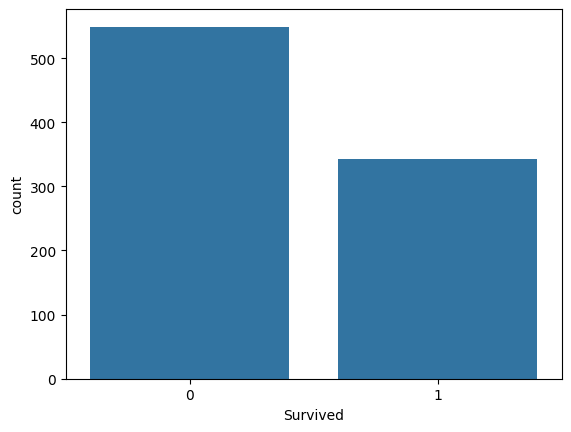

In [120]:
sns.barplot(df['Survived'].value_counts())

<Axes: xlabel='Age', ylabel='Count'>

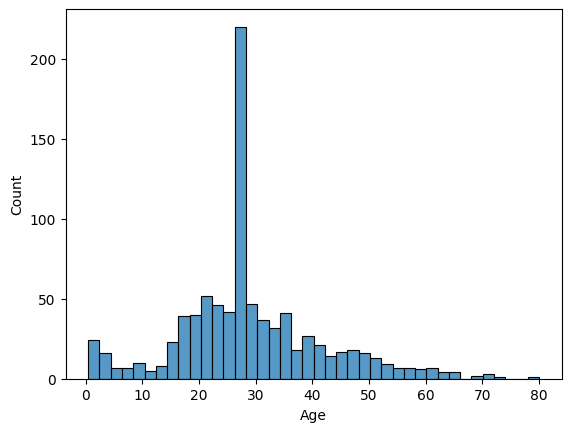

In [121]:
sns.histplot(df['Age'],bins=40)

---
## 🏗️ Step 3: Feature Engineering — Create New Features

### What to do:
**Part A — Title Extraction:**
1. Extract titles (Mr, Mrs, Miss, Master etc.) from the `Name` column using regex: `df['Name'].str.extract('([A-Za-z]+)\.')`
2. Use `value_counts()` to inspect all unique titles extracted.
3. Group rare titles (like Countess, Major, Sir, Lady etc.) into a single value called `'Rare'`.
4. Replace `Mlle` with `Miss`, `Ms` with `Miss`, and `Mme` with `Mrs`.

**Part B — Family Size:**
1. Create a new column: `df['FamilySize'] = df['SibSp'] + df['Parch'] + 1`
2. (Optional) Create an `IsAlone` column: set to `1` if `FamilySize == 1`, else `0`.

### What does this mean:
- We extract **Title** because ML models cannot directly process raw text names. However, titles capture the social status of a passenger (Mr = adult male, Master = young boy, Mrs = married female).
- **FamilySize** is created because individuals traveling alone show different survival patterns compared to those traveling with family.
- This process is called **Feature Engineering** — creating new, predictive features from existing columns.

In [122]:
df['Title']=df['Name'].str.extract('([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\sahil kumar\AppData\Local\Temp\ipykernel_10416\1906848022.py:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title']=df['Name'].str.extract('([A-Za-z]+)\.', expand=False)


In [123]:
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [124]:
# Create FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create IsAlone
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [125]:
# Rare titles ko map karo
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')


---
## 🔗 Step 4: Build Preprocessing Pipeline

### What to do:
1. **Separate Features and Target:**
   - `y = df['Survived']`
   - `X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)` — these columns are not useful for the model.
2. **Train-Test Split:** `train_test_split(X, y, test_size=0.2, random_state=42)`
3. **Identify Numeric columns:** such as `Age`, `Fare`, `SibSp`, `Parch`, `FamilySize`
4. **Identify Categorical columns:** such as `Sex`, `Embarked`, `Title`, `Pclass` 
5. **Create the Numeric pipeline** (using sklearn's `Pipeline`):
   - `SimpleImputer(strategy='median')` → fills missing Age/Fare values with the median.
   - `StandardScaler()` → scales features to have mean=0 and variance=1.
6. **Create the Categorical pipeline:**
   - `SimpleImputer(strategy='most_frequent')` → fills missing Embarked values with the most common port.
   - `OneHotEncoder(handle_unknown='ignore')` → converts text/categorical levels into 0/1 columns.
7. **Combine both pipelines** using `ColumnTransformer`.

### What does this mean:
- **SimpleImputer:** Intelligently fills missing values (median is used for numeric values to prevent outliers from biasing the mean).
- **StandardScaler:** Scales all numeric features to a similar range. Otherwise, the model might consider `Fare` (range 0-512) more important than `Age` (range 0-80).
- **OneHotEncoder:** Converts values like 'male'/'female' in the `Sex` column to `Sex_male=1, Sex_female=0` since ML models only understand numerical input.
- **Pipeline:** Chains all preprocessing steps into a single object, simplifying code and preventing leakage. This is industry standard practice.
- **ColumnTransformer:** Allows applying different preprocessing steps to numeric and categorical columns simultaneously.

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [127]:
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
categorical_features = ['Sex', 'Embarked', 'Title', 'Pclass']

In [128]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Fill holes with median
    ('scaler', StandardScaler())                  # Keep numbers balanced
])

In [129]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Fill holes with the most common value
    ('encoder', OneHotEncoder(handle_unknown='ignore'))  # Translate text to numbers
])

In [130]:
processor=ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [131]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)

---
## 🤖 Step 5: Train Logistic Regression Model

### What to do:
1. Create a final `Pipeline` that contains:
   - First step: Your `ColumnTransformer` preprocessor (from Step 4)
   - Second step: `LogisticRegression(max_iter=1000)`
2. Fit this pipeline on `X_train` and `y_train` using `.fit()`.

### What does this mean:
- **Logistic Regression** is a classification algorithm that predicts whether a binary event will occur (0 or 1).
- Internally, it outputs a probability (between 0.0 and 1.0). If probability > 0.5, it predicts `1` (Survived), else `0` (Died).
- `.fit()` allows the model to **learn** from the training data by adjusting coefficients/weights to minimize errors.
- `max_iter=1000` is set to ensure the optimization solver has enough iterations to converge.

In [132]:
from sklearn.linear_model import LogisticRegression

In [133]:
pipeline=Pipeline([
    ('columntransformer',processor),
    ('model',LogisticRegression(max_iter=1000))
])

In [134]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

---
## 🎯 Step 6: Make Predictions and Evaluate Baseline Accuracy

### What to do:
1. Call `.predict()` on `X_test` and store the predictions in `y_pred`.
2. Compute accuracy using `accuracy_score(y_test, y_pred)`.
3. Print: `f'Baseline Accuracy: {accuracy:.2%}'`.

### What does this mean:
- We are testing how well the model generalizes to **new, unseen data** (the test set).
- You should get roughly **78-82% accuracy** — which serves as a solid baseline.
- Tomorrow (Day 2 / Part 2), we will explore detailed evaluation metrics: Confusion Matrix, ROC-AUC, F1-Score, GridSearchCV hyperparameter tuning, and threshold optimization.

---
### ✅ Day 1 Complete! Tomorrow in Part 2:
- Confusion Matrix & Classification Report
- ROC Curve & AUC Score
- Hyperparameter Tuning via GridSearchCV
- Decision Threshold Tuning

In [135]:
y_pred=pipeline.predict(X_test)

In [136]:
from sklearn.metrics import accuracy_score

In [137]:
print(f"Accuracy score:{accuracy_score(y_test,y_pred):.2f}")

Accuracy score:0.81


In [138]:
c=pipeline.predict_proba(X_test)[0,1]

In [139]:
c

np.float64(0.5798789118976566)